# Zmiana bazy

Niech $B_1$ będzie bazą starą, a $B_2$ nową. Kolumny macierzy przejścia $P$ zawierają współrzędne wektorów bazy $B_2$ zapisane w bazie $B_1$. Dla tego samego wektora $v$ zachodzi

$$[v]_{B_1} = P [v]_{B_2}, \qquad [v]_{B_2} = P^{-1}[v]_{B_1}.$$

Poniżej SymPy wyprowadza te zależności dla ogólnej macierzy $2\times 2$, a następnie sprawdzamy je na konkretnych bazach.

In [1]:
import sympy as sp
from IPython.display import display

a, b, c, d = sp.symbols("a b c d")
x1, x2 = sp.symbols("x_1 x_2")
x1_new, x2_new = sp.symbols("x_1' x_2'")

P = sp.Matrix([[a, b], [c, d]])
coordinates_old = sp.Matrix([x1, x2])
coordinates_new = sp.Matrix([x1_new, x2_new])

print("Macierz przejścia P:")
display(P)
print("Warunek, aby kolumny P tworzyły nową bazę:")
display(sp.Ne(P.det(), 0))

Macierz przejścia P:


Matrix([
[a, b],
[c, d]])

Warunek, aby kolumny P tworzyły nową bazę:


Ne(a*d - b*c, 0)

Współrzędne w starej bazie otrzymujemy przez mnożenie przez $P$. Mnożenie przez macierz odwrotną daje współrzędne w bazie nowej.

In [2]:
print("[v]_B1 = P [v]_B2 =")
display(P * coordinates_new)

P_inverse = P.inv()
print("Macierz odwrotna P^(-1) =")
display(P_inverse)

print("[v]_B2 = P^(-1) [v]_B1 =")
display(P_inverse * coordinates_old)

[v]_B1 = P [v]_B2 =


Matrix([
[a*x_1' + b*x_2'],
[c*x_1' + d*x_2']])

Macierz odwrotna P^(-1) =


Matrix([
[ d/(a*d - b*c), -b/(a*d - b*c)],
[-c/(a*d - b*c),  a/(a*d - b*c)]])

[v]_B2 = P^(-1) [v]_B1 =


Matrix([
[-b*x_2/(a*d - b*c) + d*x_1/(a*d - b*c)],
[ a*x_2/(a*d - b*c) - c*x_1/(a*d - b*c)]])

## Przykład liczbowy

W starej bazie standardowej przyjmijmy nową bazę $B_2 = ((2,1),(1,2))$. Rozważmy wektor o współrzędnych $(2,1)$ w bazie $B_2$ i przeliczmy je na obie bazy.

In [3]:
P_example = sp.Matrix([[2, 1], [1, 2]])
coordinates_new_example = sp.Matrix([2, 1])
coordinates_old_example = P_example * coordinates_new_example
coordinates_new_check = P_example.inv() * coordinates_old_example

print("Macierz przejścia P:")
display(P_example)
print(f"det(P) = {P_example.det()}")
print("Współrzędne w nowej bazie [v]_B2:")
display(coordinates_new_example)
print("Współrzędne w starej bazie [v]_B1 = P [v]_B2:")
display(coordinates_old_example)
print("Kontrola: P^(-1) [v]_B1 =")
display(coordinates_new_check)

assert coordinates_new_check == coordinates_new_example

Macierz przejścia P:


Matrix([
[2, 1],
[1, 2]])

det(P) = 3
Współrzędne w nowej bazie [v]_B2:


Matrix([
[2],
[1]])

Współrzędne w starej bazie [v]_B1 = P [v]_B2:


Matrix([
[5],
[4]])

Kontrola: P^(-1) [v]_B1 =


Matrix([
[2],
[1]])

Na rysunku obie bazy i wektor $v$ są przedstawione w tej samej płaszczyźnie. Przerywane odcinki pokazują rozkład $v = 2e_1' + e_2'$.

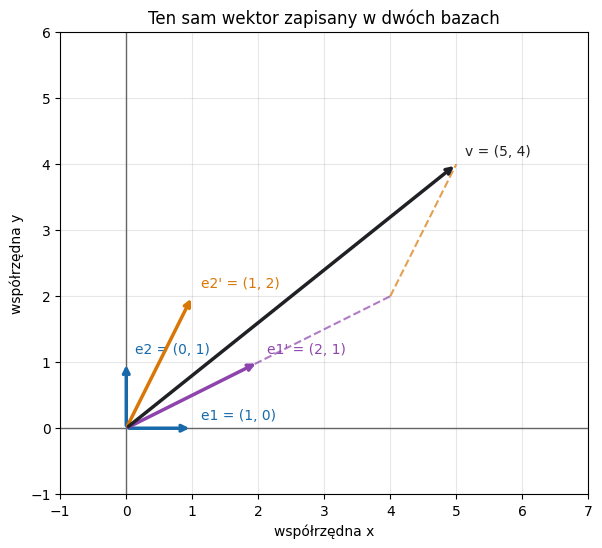

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))
ax.axhline(0, color="0.4", linewidth=1)
ax.axvline(0, color="0.4", linewidth=1)
ax.grid(True, alpha=0.3)

vectors = [
    ((1, 0), "e1 = (1, 0)", "#1769aa"),
    ((0, 1), "e2 = (0, 1)", "#1769aa"),
    ((2, 1), "e1' = (2, 1)", "#8e44ad"),
    ((1, 2), "e2' = (1, 2)", "#d97706"),
    ((5, 4), "v = (5, 4)", "#202124"),
]
for (x, y), label, color in vectors:
    ax.annotate("", xy=(x, y), xytext=(0, 0),
                arrowprops={"arrowstyle": "->", "color": color, "lw": 2.5})
    ax.annotate(label, (x, y), xytext=(6, 6), textcoords="offset points",
                color=color)

ax.plot([0, 4], [0, 2], "--", color="#8e44ad", alpha=0.7)
ax.plot([4, 5], [2, 4], "--", color="#d97706", alpha=0.7)
ax.set(xlim=(-1, 7), ylim=(-1, 6), aspect="equal",
       title="Ten sam wektor zapisany w dwóch bazach",
       xlabel="współrzędna x", ylabel="współrzędna y")
plt.show()